In [ ]:
# =========================================================================================
# Курсовой проект: поиск и первичный анализ наборов данных по различным областям применения
# Кейс: 58 - Прогнозирование стоимости медицинской страховки
# Выполнила: Палеева Виктория Станиславовна, группа ЕТ-142
# Дата: 13.04.2026
# =========================================================================================
# Программа для первичного анализа набора табличных данных
# 1.2 Перечень всех признаков (включая целевые)
# =========================================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

# Загрузка данных
df = pd.read_csv('/content/insurance.csv')
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max


1.2.1. ДИАГРАММЫ РАСПРЕДЕЛЕНИЯ ЧИСЛОВЫХ ПРИЗНАКОВ
График сохранён в: C:\Users\palee\Google Диск\Школа\хелп\Проектная деятельность/распределение_числовых_признаков.png


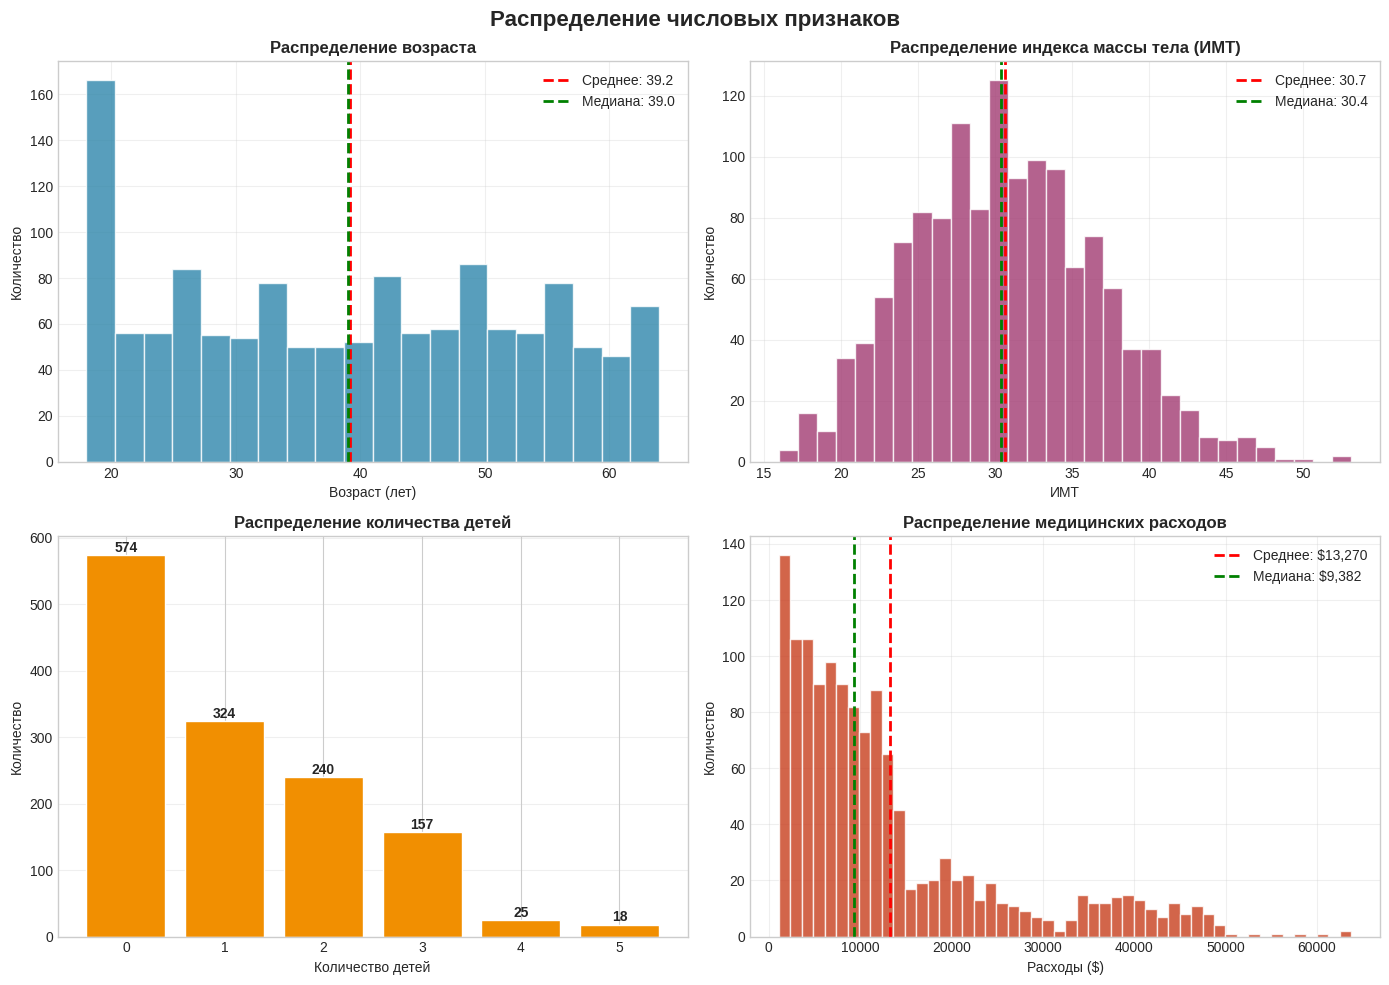

In [ ]:
# =========================================================================================
# 1.3 Характеристика числовых признаков
# 1.3.1	Диаграммы распределения
# =========================================================================================
# Настройка стиля и цветовой палитры
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E']
sns.set_palette(colors)

print("\n" + "=" * 60)
print("1.2.1. ДИАГРАММЫ РАСПРЕДЕЛЕНИЯ ЧИСЛОВЫХ ПРИЗНАКОВ")
print("=" * 60)

# Выбираем только числовые признаки
numeric_cols = ['age', 'bmi', 'children', 'charges']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Распределение числовых признаков', fontsize=16, fontweight='bold')

# 1. Возраст
axes[0, 0].hist(df['age'], bins=20, edgecolor='white', color=colors[0], alpha=0.8)
axes[0, 0].axvline(df['age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее: {df["age"].mean():.1f}')
axes[0, 0].axvline(df['age'].median(), color='green', linestyle='--', linewidth=2, label=f'Медиана: {df["age"].median():.1f}')
axes[0, 0].set_title('Распределение возраста', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Возраст (лет)')
axes[0, 0].set_ylabel('Количество')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. ИМТ
axes[0, 1].hist(df['bmi'], bins=30, edgecolor='white', color=colors[1], alpha=0.8)
axes[0, 1].axvline(df['bmi'].mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее: {df["bmi"].mean():.1f}')
axes[0, 1].axvline(df['bmi'].median(), color='green', linestyle='--', linewidth=2, label=f'Медиана: {df["bmi"].median():.1f}')
axes[0, 1].set_title('Распределение индекса массы тела (ИМТ)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('ИМТ')
axes[0, 1].set_ylabel('Количество')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Количество детей
children_counts = df['children'].value_counts().sort_index()
axes[1, 0].bar(children_counts.index.astype(str), children_counts.values, color=colors[2], edgecolor='white')
axes[1, 0].set_title('Распределение количества детей', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Количество детей')
axes[1, 0].set_ylabel('Количество')
for i, v in enumerate(children_counts.values):
    axes[1, 0].text(i, v + 5, str(v), ha='center', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Медицинские расходы
axes[1, 1].hist(df['charges'], bins=50, edgecolor='white', color=colors[3], alpha=0.8)
axes[1, 1].axvline(df['charges'].mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее: ${df["charges"].mean():,.0f}')
axes[1, 1].axvline(df['charges'].median(), color='green', linestyle='--', linewidth=2, label=f'Медиана: ${df["charges"].median():,.0f}')
axes[1, 1].set_title('Распределение медицинских расходов', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Расходы ($)')
axes[1, 1].set_ylabel('Количество')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()

# === СОХРАНЕНИЕ ГРАФИКА ===
output_dir = r"C:\Users\palee\Google Диск\Школа\хелп\Проектная деятельность"
# Создаём папку, если её нет
os.makedirs(output_dir, exist_ok=True)
# Формируем полный путь к файлу
output_path = os.path.join(output_dir, "распределение_числовых_признаков.png")
# Сохраняем с высоким разрешением
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"График сохранён в: {output_path}")

plt.show()




1.2.2. ВИЗУАЛИЗАЦИЯ ПРИЗНАКОВ СРЕДСТВАМИ SEABORN
График 1 сохранён в: C:\Users\palee\Google Диск\Школа\хелп\Проектная деятельность/pair_age_charges_regplot.png


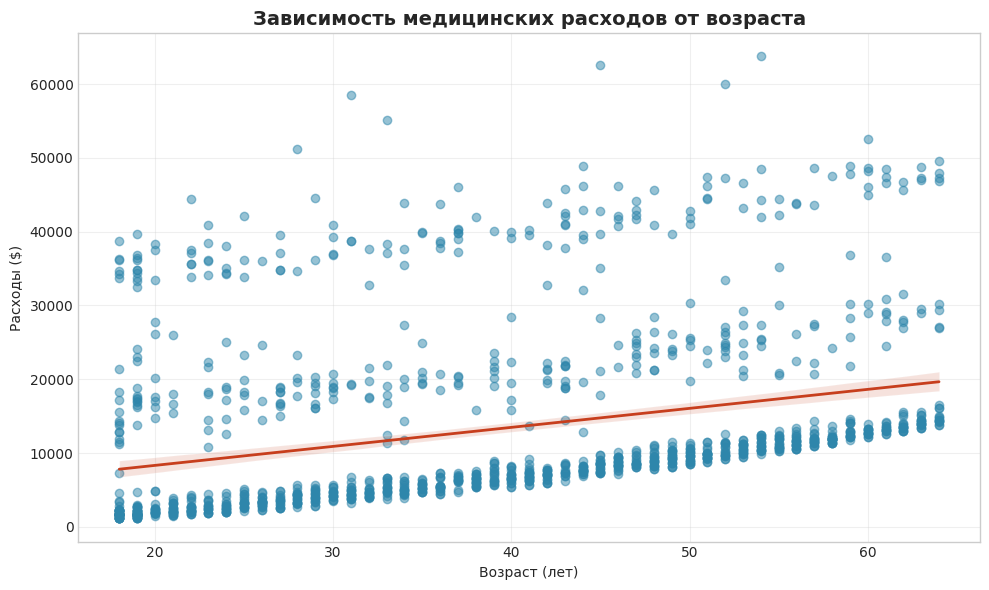

График 2 сохранён в: C:\Users\palee\Google Диск\Школа\хелп\Проектная деятельность/pair_bmi_charges_regplot.png


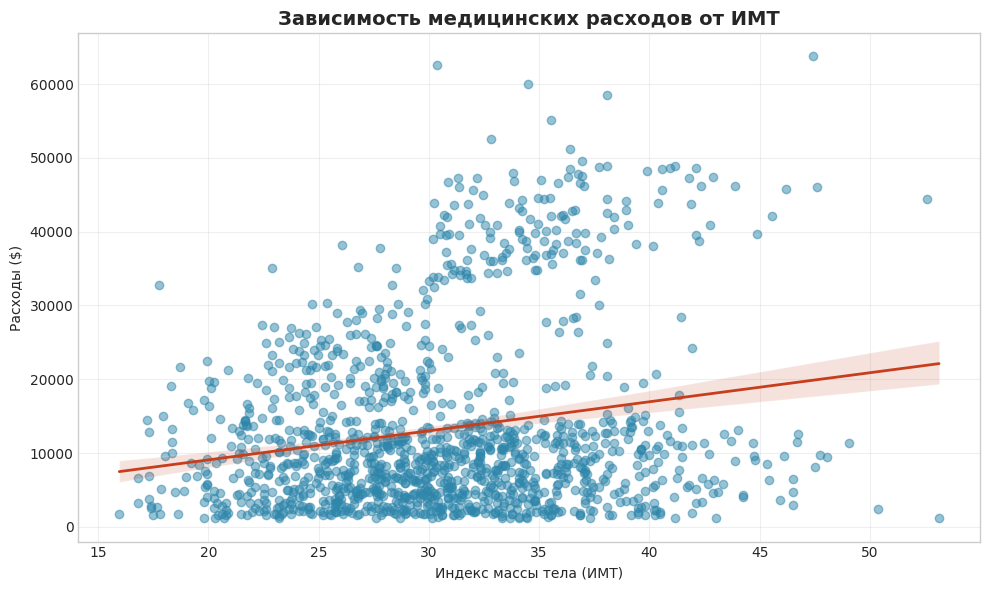

График 3 сохранён в: C:\Users\palee\Google Диск\Школа\хелп\Проектная деятельность/pair_children_charges_regplot.png


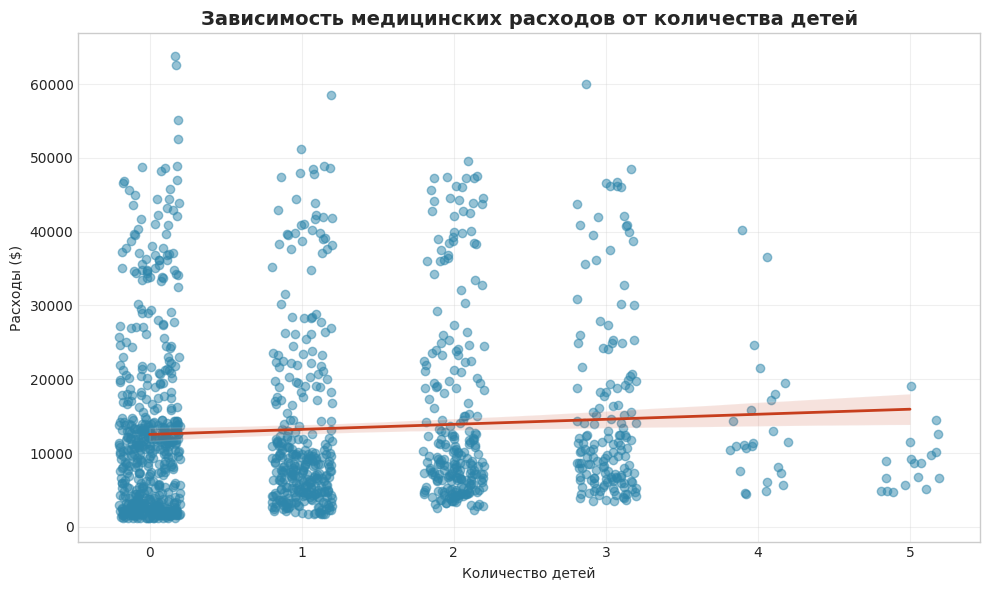


Все графики раздела 1.2.2 успешно сохранены.


In [ ]:
# =========================================================================================
# 1.3 Характеристика числовых признаков
# 1.3.2 Визуализация признаков средствами библиотеки seaborn
# =========================================================================================
# Настройка стиля
sns.set_style("whitegrid")

# === Путь для сохранения ===
output_dir = r"C:\Users\palee\Google Диск\Школа\хелп\Проектная деятельность"
os.makedirs(output_dir, exist_ok=True)

print("\n" + "=" * 60)
print("1.2.2. ВИЗУАЛИЗАЦИЯ ПРИЗНАКОВ СРЕДСТВАМИ SEABORN")
print("=" * 60)

# Общие параметры графиков
figsize = (10, 6)
scatter_color = '#2E86AB'
line_color = '#C73E1D'

# ---------- 1. Возраст и медицинские расходы ----------
plt.figure(figsize=figsize)
sns.regplot(data=df, x='age', y='charges',
            scatter_kws={'alpha':0.5, 'color':scatter_color},
            line_kws={'color':line_color, 'lw':2})
plt.title('Зависимость медицинских расходов от возраста', fontsize=14, fontweight='bold')
plt.xlabel('Возраст (лет)')
plt.ylabel('Расходы ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()

path1 = os.path.join(output_dir, 'pair_age_charges_regplot.png')
plt.savefig(path1, dpi=300, bbox_inches='tight')
print(f"График 1 сохранён в: {path1}")
plt.show()

# ---------- 2. ИМТ и медицинские расходы ----------
plt.figure(figsize=figsize)
sns.regplot(data=df, x='bmi', y='charges',
            scatter_kws={'alpha':0.5, 'color':scatter_color},
            line_kws={'color':line_color, 'lw':2})
plt.title('Зависимость медицинских расходов от ИМТ', fontsize=14, fontweight='bold')
plt.xlabel('Индекс массы тела (ИМТ)')
plt.ylabel('Расходы ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()

path2 = os.path.join(output_dir, 'pair_bmi_charges_regplot.png')
plt.savefig(path2, dpi=300, bbox_inches='tight')
print(f"График 2 сохранён в: {path2}")
plt.show()

# ---------- 3. Количество детей и медицинские расходы ----------
plt.figure(figsize=figsize)
sns.regplot(data=df, x='children', y='charges',
            scatter_kws={'alpha':0.5, 'color':scatter_color},
            line_kws={'color':line_color, 'lw':2},
            x_jitter=0.2)
plt.title('Зависимость медицинских расходов от количества детей', fontsize=14, fontweight='bold')
plt.xlabel('Количество детей')
plt.ylabel('Расходы ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()

path3 = os.path.join(output_dir, 'pair_children_charges_regplot.png')
plt.savefig(path3, dpi=300, bbox_inches='tight')
print(f"График 3 сохранён в: {path3}")
plt.show()

print("\nВсе графики раздела 1.2.2 успешно сохранены.")

In [ ]:
# =========================================================================================
# 1.3 Характеристика числовых признаков
# 1.3.3 Визуализация признаков средствами библиотеки pyplot
# =========================================================================================
import ipywidgets as widgets
from IPython.display import display

# Настройка стиля
plt.style.use('seaborn-v0_8-whitegrid')

# Папка для сохранения
output_dir = r"C:\Users\palee\Google Диск\Школа\хелп\Проектная деятельность"
if not os.path.exists(output_dir):
    os.makedirs(output_dir, exist_ok=True)

print("\n" + "=" * 60)
print("1.3.3. ИНТЕРАКТИВНЫЕ ГРАФИКИ С ПОМОЩЬЮ PYPLOT")
print("=" * 60)

# Список числовых признаков для выбора
numeric_features = ['age', 'bmi', 'children', 'charges']

# ---------- 1. Интерактивный scatter plot с выбором осей ----------
def plot_scatter(x_var, y_var):
    plt.figure(figsize=(8, 6))
    plt.scatter(df[x_var], df[y_var], alpha=0.5, c='#2E86AB', edgecolors='w', s=50)
    plt.xlabel(x_var)
    plt.ylabel(y_var)
    plt.title(f'Зависимость {y_var} от {x_var}')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Создаём виджеты: два выпадающих списка
x_dropdown = widgets.Dropdown(
    options=numeric_features,
    value='age',
    description='Ось X:',
    disabled=False
)
y_dropdown = widgets.Dropdown(
    options=numeric_features,
    value='charges',
    description='Ось Y:',
    disabled=False
)

# Интерактивный вывод
interactive_plot = widgets.interactive(plot_scatter, x_var=x_dropdown, y_var=y_dropdown)
display(interactive_plot)

# ---------- 2. Интерактивная гистограмма с выбором признака и числа бинов ----------
def plot_histogram(feature, bins):
    plt.figure(figsize=(8, 6))
    plt.hist(df[feature], bins=bins, color='#A23B72', edgecolor='white', alpha=0.8)
    plt.xlabel(feature)
    plt.ylabel('Частота')
    plt.title(f'Гистограмма признака {feature} (bins={bins})')
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

feature_dropdown = widgets.Dropdown(
    options=numeric_features,
    value='bmi',
    description='Признак:'
)
bins_slider = widgets.IntSlider(
    value=30,
    min=5,
    max=100,
    step=5,
    description='Число бинов:',
    continuous_update=False
)

interactive_hist = widgets.interactive(plot_histogram, feature=feature_dropdown, bins=bins_slider)
display(interactive_hist)


1.3.3. ИНТЕРАКТИВНЫЕ ГРАФИКИ С ПОМОЩЬЮ PYPLOT


interactive(children=(Dropdown(description='Ось X:', options=('age', 'bmi', 'children', 'charges'), value='age…

interactive(children=(Dropdown(description='Признак:', index=1, options=('age', 'bmi', 'children', 'charges'),…


1.3.5. ПОСТРОЕНИЕ ТЕПЛОВЫХ КАРТ
Тепловая карта корреляций сохранена: C:\Users\palee\Google Диск\Школа\хелп\Проектная деятельность/heatmap_correlation.png


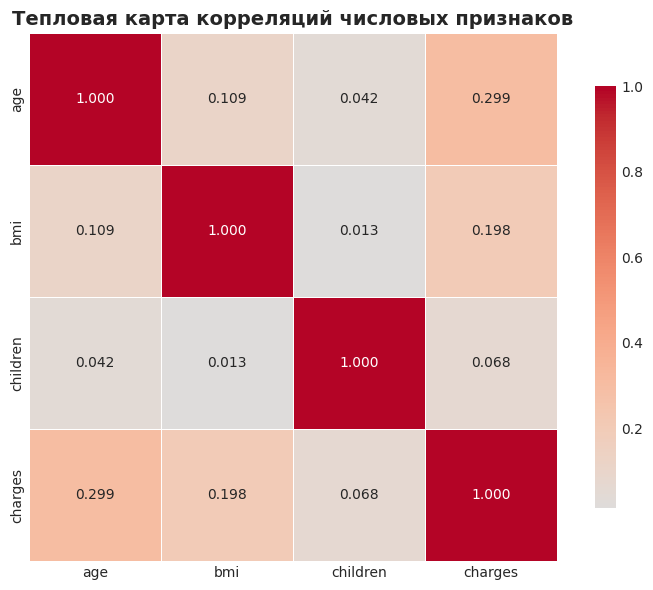

Тепловая карта курящих по регионам сохранена: C:\Users\palee\Google Диск\Школа\хелп\Проектная деятельность/heatmap_smoker_region.png


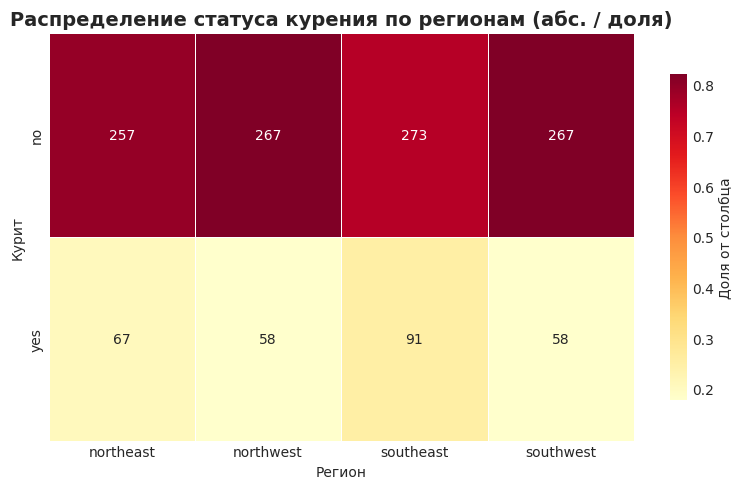


Все тепловые карты успешно построены и сохранены.


In [ ]:
# =========================================================================================
# 1.3 Характеристика числовых признаков
# 1.3.5	Построение тепловой карты
# =========================================================================================
# Настройка стиля
sns.set_style("white")
output_dir = r"C:\Users\palee\Google Диск\Школа\хелп\Проектная деятельность"
os.makedirs(output_dir, exist_ok=True)

print("\n" + "=" * 60)
print("1.3.5. ПОСТРОЕНИЕ ТЕПЛОВЫХ КАРТ")
print("=" * 60)

# ---------- 1. Тепловая карта корреляционной матрицы числовых признаков ----------
numeric_cols = ['age', 'bmi', 'children', 'charges']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix,
            annot=True,            # отображать значения
            fmt='.3f',             # формат чисел
            cmap='coolwarm',       # цветовая схема: холодные - отрицательная, тёплые - положительная корреляция
            center=0,              # центр цветовой шкалы на 0
            square=True,           # квадратные ячейки
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Тепловая карта корреляций числовых признаков', fontsize=14, fontweight='bold')
plt.tight_layout()

path_corr = os.path.join(output_dir, 'heatmap_correlation.png')
plt.savefig(path_corr, dpi=300, bbox_inches='tight')
print(f"Тепловая карта корреляций сохранена: {path_corr}")
plt.show()

# ---------- 2. Тепловая карта распределения курящих по регионам ----------
# Создаём таблицу сопряжённости: строки - smoker, столбцы - region
cross_tab = pd.crosstab(df['smoker'], df['region'])
# Нормируем по столбцам для отображения доли курящих в каждом регионе
cross_tab_norm = pd.crosstab(df['smoker'], df['region'], normalize='columns')

plt.figure(figsize=(8, 5))
sns.heatmap(cross_tab_norm,
            annot=cross_tab,       # абсолютные числа в ячейках
            fmt='d',
            cmap='YlOrRd',         # от светлого к тёмному для частот
            linewidths=0.5,
            cbar_kws={"label": "Доля от столбца", "shrink": 0.8})
plt.title('Распределение статуса курения по регионам (абс. / доля)', fontsize=14, fontweight='bold')
plt.xlabel('Регион')
plt.ylabel('Курит')
plt.tight_layout()

path_region = os.path.join(output_dir, 'heatmap_smoker_region.png')
plt.savefig(path_region, dpi=300, bbox_inches='tight')
print(f"Тепловая карта курящих по регионам сохранена: {path_region}")
plt.show()

print("\nВсе тепловые карты успешно построены и сохранены.")

✅ График сохранён как 'boxplot_features.png'


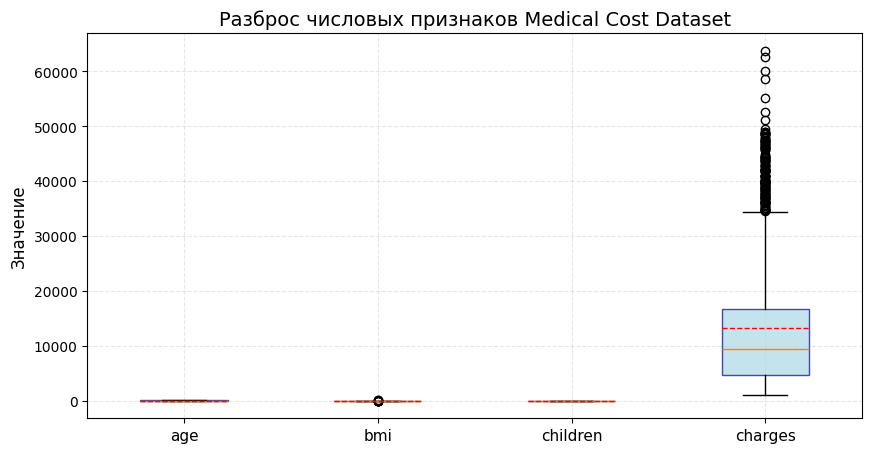

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Загрузка данных
df = pd.read_csv('insurance.csv')

# Создание графика
fig, ax = plt.subplots(figsize=(10, 5))

# Цветная коробочная диаграмма (синяя)
box = ax.boxplot(df[['age', 'bmi', 'children', 'charges']],
                 patch_artist=True,  # чтобы залить цветом
                 showmeans=True,      # показать среднее
                 meanline=True,       # среднее как линия
                 meanprops={'color': 'red', 'linestyle': '--'})

# Заливаем коробочки синим цветом
for patch in box['boxes']:
    patch.set_facecolor('lightblue')
    patch.set_edgecolor('darkblue')
    patch.set_alpha(0.7)

# Настройка подписей
ax.set_title('Разброс числовых признаков Medical Cost Dataset', fontsize=14)
ax.set_ylabel('Значение', fontsize=12)
ax.set_xticklabels(['age', 'bmi', 'children', 'charges'], fontsize=11)

# Сетка для удобства чтения
ax.grid(True, alpha=0.3, linestyle='--')

# Сохранение в PNG
plt.savefig('boxplot_features.png', dpi=300, bbox_inches='tight')
print("✅ График сохранён как 'boxplot_features.png'")

# Показать график
plt.show()

In [ ]:
# =========================================================================================
# 1.3 Характеристика числовых признаков
# 1.3.6	Устранение дубликатов строк
# =========================================================================================
print("=" * 60)
print("1.3.6. УСТРАНЕНИЕ ДУБЛИКАТОВ СТРОК")
print("=" * 60)

# 1. Проверка наличия дубликатов
initial_shape = df.shape
duplicates_count = df.duplicated().sum()
print(f"\nИсходный размер датасета: {initial_shape[0]} строк, {initial_shape[1]} столбцов")
print(f"Количество полных дубликатов строк: {duplicates_count}")

# 2. Вывод примеров дубликатов (если есть)
if duplicates_count > 0:
    print("\nПримеры дублированных строк:")
    # Показываем все вхождения дубликатов (первые несколько групп)
    duplicated_rows = df[df.duplicated(keep=False)].sort_values(by=list(df.columns))
    display(duplicated_rows.head(10))
else:
    print("\nПолные дубликаты не обнаружены.")

# 3. Удаление дубликатов с сохранением первого вхождения
df_cleaned = df.drop_duplicates(keep='first')
final_shape = df_cleaned.shape
removed = initial_shape[0] - final_shape[0]
print(f"\nПосле удаления дубликатов: {final_shape[0]} строк (удалено {removed} дубликатов)")

# 4. Сохранение очищенного датасета
output_dir = r"C:\Users\palee\Google Диск\Школа\хелп\Проектная деятельность"
os.makedirs(output_dir, exist_ok=True)
cleaned_path = os.path.join(output_dir, 'insurance_cleaned.csv')
df_cleaned.to_csv(cleaned_path, index=False)
print(f"\nОчищенный датасет сохранён в: {cleaned_path}")

# Заменяем исходный df на очищенный для дальнейшей работы
df = df_cleaned

1.3.6. УСТРАНЕНИЕ ДУБЛИКАТОВ СТРОК

Исходный размер датасета: 1338 строк, 7 столбцов
Количество полных дубликатов строк: 1

Примеры дублированных строк:


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631



После удаления дубликатов: 1337 строк (удалено 1 дубликатов)

Очищенный датасет сохранён в: C:\Users\palee\Google Диск\Школа\хелп\Проектная деятельность/insurance_cleaned.csv



1.3.7. АНАЛИЗ НЕТИПИЧНЫХ ВЫБРОСОВ ПО ПРИЗНАКАМ
Boxplot сохранён: C:\Users\palee\Google Диск\Школа\хелп\Проектная деятельность/boxplots_outliers.png


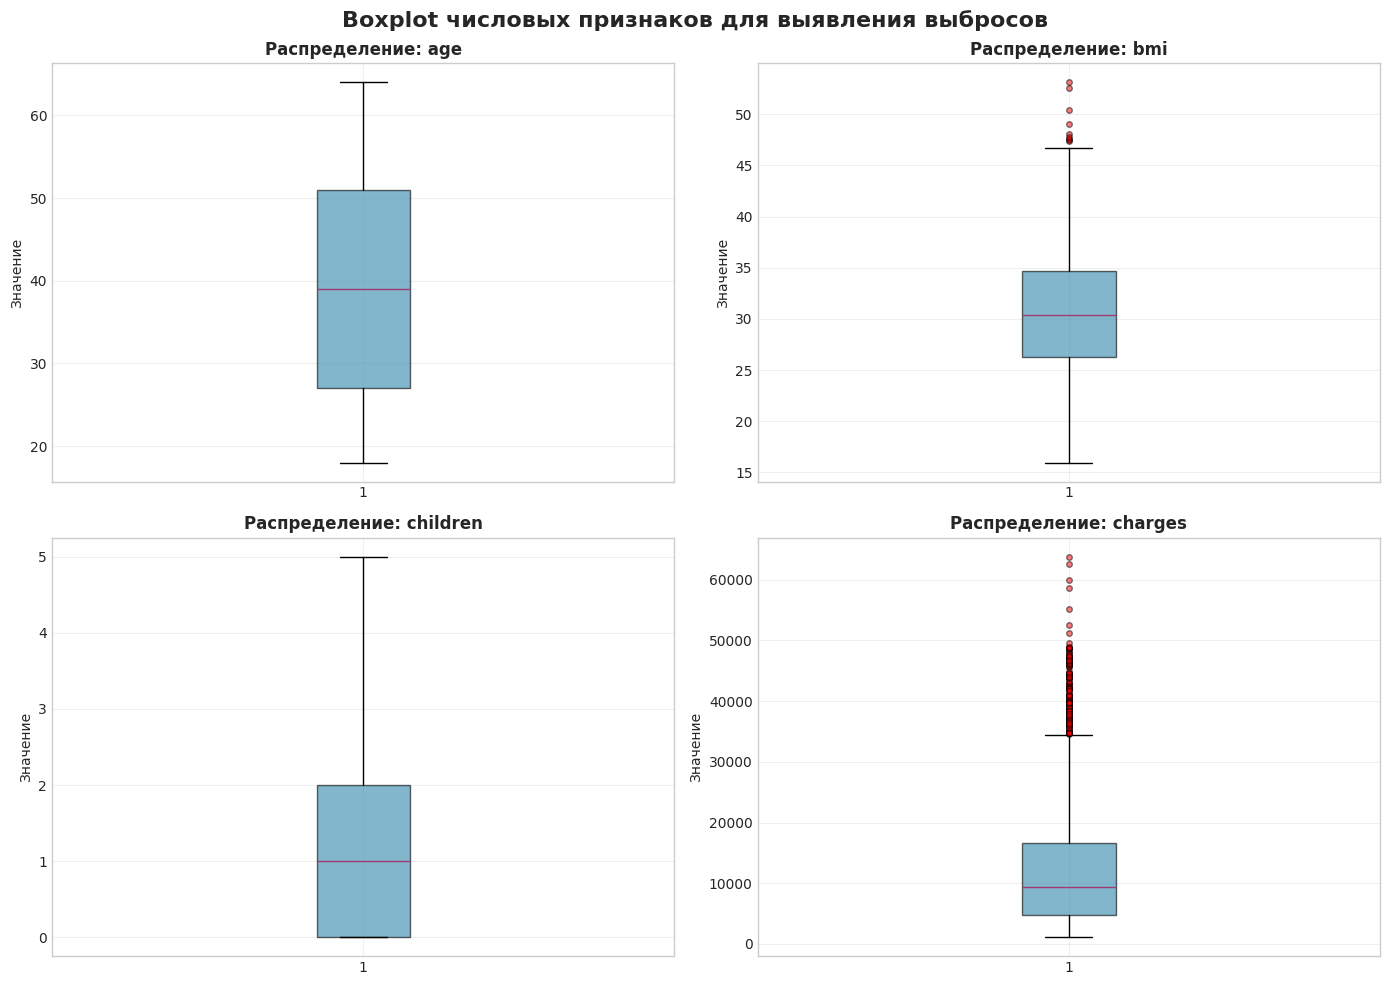


Результаты обнаружения выбросов по правилу IQR (1.5*IQR):
----------------------------------------------------------------------
Признак: age
  Q1 = 27.000, Q3 = 51.000, IQR = 24.000
  Границы выбросов: [-9.000, 87.000]
  Количество выбросов: 0 (0.00%)

Признак: bmi
  Q1 = 26.296, Q3 = 34.694, IQR = 8.398
  Границы выбросов: [13.700, 47.290]
  Количество выбросов: 9 (0.67%)

Признак: children
  Q1 = 0.000, Q3 = 2.000, IQR = 2.000
  Границы выбросов: [-3.000, 5.000]
  Количество выбросов: 0 (0.00%)

Признак: charges
  Q1 = 4740.287, Q3 = 16639.913, IQR = 11899.625
  Границы выбросов: [-13109.151, 34489.351]
  Количество выбросов: 139 (10.39%)

Примеры записей с аномально высокими расходами (всего 139):


,age,sex,bmi,children,smoker,region,charges
543,54,female,47.410,0,yes,southeast,63770.42801
1300,45,male,30.360,0,yes,southeast,62592.87309
1230,52,male,34.485,3,yes,northwest,60021.39897
577,31,female,38.095,1,yes,northeast,58571.07448
819,33,female,35.530,0,yes,northwest,55135.40209
1146,60,male,32.800,0,yes,southwest,52590.82939
34,28,male,36.400,1,yes,southwest,51194.55914
1241,64,male,36.960,2,yes,southeast,49577.66240
1062,59,male,41.140,1,yes,southeast,48970.24760
488,44,female,38.060,0,yes,southeast,48885.13561



Количество выбросов по BMI: 9 (в основном высокие значения)
Диапазон выбросов BMI: от 47.4 до 53.1


In [ ]:
# =========================================================================================
# 1.3 Характеристика числовых признаков
# 1.3.7	Появление нетипичных выбросов по признакам
# =========================================================================================
# Настройка стиля
sns.set_style("whitegrid")
output_dir = r"C:\Users\palee\Google Диск\Школа\хелп\Проектная деятельность"
os.makedirs(output_dir, exist_ok=True)

print("\n" + "=" * 60)
print("1.3.7. АНАЛИЗ НЕТИПИЧНЫХ ВЫБРОСОВ ПО ПРИЗНАКАМ")
print("=" * 60)

numeric_cols = ['age', 'bmi', 'children', 'charges']

# ---------- 1. Визуализация boxplot ----------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Boxplot числовых признаков для выявления выбросов', fontsize=16, fontweight='bold')

for i, col in enumerate(numeric_cols):
    row, col_idx = divmod(i, 2)
    axes[row, col_idx].boxplot(df[col], vert=True, patch_artist=True,
                               boxprops=dict(facecolor='#2E86AB', alpha=0.6),
                               flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.5))
    axes[row, col_idx].set_title(f'Распределение: {col}', fontsize=12, fontweight='bold')
    axes[row, col_idx].set_ylabel('Значение')
    axes[row, col_idx].grid(True, alpha=0.3)

plt.tight_layout()
boxplot_path = os.path.join(output_dir, 'boxplots_outliers.png')
plt.savefig(boxplot_path, dpi=300, bbox_inches='tight')
print(f"Boxplot сохранён: {boxplot_path}")
plt.show()

# ---------- 2. Количественный анализ выбросов методом IQR ----------
def detect_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    return {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'outliers_count': len(outliers),
        'outliers_percent': 100 * len(outliers) / len(data)
    }

print("\nРезультаты обнаружения выбросов по правилу IQR (1.5*IQR):")
print("-" * 70)
for col in numeric_cols:
    res = detect_outliers_iqr(df, col)
    print(f"Признак: {col}")
    print(f"  Q1 = {res['Q1']:.3f}, Q3 = {res['Q3']:.3f}, IQR = {res['IQR']:.3f}")
    print(f"  Границы выбросов: [{res['lower_bound']:.3f}, {res['upper_bound']:.3f}]")
    print(f"  Количество выбросов: {res['outliers_count']} ({res['outliers_percent']:.2f}%)")
    print()

# ---------- 3. Детальный анализ выбросов в charges ----------
charges_outliers = df[(df['charges'] > detect_outliers_iqr(df, 'charges')['upper_bound'])]
print(f"Примеры записей с аномально высокими расходами (всего {len(charges_outliers)}):")
display(charges_outliers.sort_values('charges', ascending=False).head(10))

# ---------- 4. Анализ выбросов BMI ----------
bmi_lower = detect_outliers_iqr(df, 'bmi')['lower_bound']
bmi_upper = detect_outliers_iqr(df, 'bmi')['upper_bound']
bmi_outliers = df[(df['bmi'] < bmi_lower) | (df['bmi'] > bmi_upper)]
print(f"\nКоличество выбросов по BMI: {len(bmi_outliers)} (в основном высокие значения)")
print(f"Диапазон выбросов BMI: от {bmi_outliers['bmi'].min():.1f} до {bmi_outliers['bmi'].max():.1f}")

In [ ]:
# =========================================================================================
# 1.3 Характеристика числовых признаков
# 1.3.8	Условная фильтрация сэмплов
# =========================================================================================
print("=" * 60)
print("1.3.8. УСЛОВНАЯ ФИЛЬТРАЦИЯ СЭМПЛОВ")
print("=" * 60)

output_dir = r"C:\Users\palee\Google Диск\Школа\хелп\Проектная деятельность"
os.makedirs(output_dir, exist_ok=True)

total = len(df)

# ---------- Пример 1: Фильтрация по одному категориальному признаку ----------
print("\n--- Пример 1: Отбор только курящих клиентов (smoker == 'yes') ---")
smokers_df = df[df['smoker'] == 'yes']
smokers_count = len(smokers_df)
smokers_ratio = 100 * smokers_count / total
print(f"Исходное количество записей: {total}")
print(f"Количество курящих: {smokers_count}")
print(f"Соотношение: {smokers_ratio:.2f}% от общего числа")
print("Первые 5 записей выборки:")
display(smokers_df.head())

smokers_path = os.path.join(output_dir, 'filtered_smokers.csv')
smokers_df.to_csv(smokers_path, index=False)
print(f"Выборка сохранена в: {smokers_path}")

# ---------- Пример 2: Фильтрация по одному числовому признаку ----------
print("\n--- Пример 2: Отбор клиентов старше 50 лет (age > 50) ---")
senior_df = df[df['age'] > 50]
senior_count = len(senior_df)
senior_ratio = 100 * senior_count / total
print(f"Количество клиентов старше 50 лет: {senior_count}")
print(f"Соотношение: {senior_ratio:.2f}% от общего числа")
print(f"Диапазон возраста в выборке: от {senior_df['age'].min()} до {senior_df['age'].max()} лет")
print("Примеры записей (случайные 5):")
display(senior_df.sample(5, random_state=42))

senior_path = os.path.join(output_dir, 'filtered_age_gt50.csv')
senior_df.to_csv(senior_path, index=False)
print(f"Выборка сохранена в: {senior_path}")

# ---------- Пример 3: Фильтрация по нескольким признакам ----------
print("\n--- Пример 3: Отбор курящих с ожирением (bmi >= 30) и расходами выше медианного значения ---")
median_charges = df['charges'].median()
obese_smokers_highcharges_df = df[(df['smoker'] == 'yes') &
                                   (df['bmi'] >= 30) &
                                   (df['charges'] > median_charges)]
obese_count = len(obese_smokers_highcharges_df)
obese_ratio = 100 * obese_count / total
print(f"Медианные расходы по всему датасету: ${median_charges:,.2f}")
print(f"Количество записей, удовлетворяющих всем трём условиям: {obese_count}")
print(f"Соотношение: {obese_ratio:.2f}% от общего числа")
print("Примеры (первые 5 записей):")
display(obese_smokers_highcharges_df.head())

obese_path = os.path.join(output_dir, 'filtered_obese_smokers_highcharges.csv')
obese_smokers_highcharges_df.to_csv(obese_path, index=False)
print(f"Выборка сохранена в: {obese_path}")

# ---------- Дополнительно: подсчёт средних расходов в разных группах ----------
print("\n--- Сравнение средних расходов ---")
print(f"Средние расходы среди всех клиентов: ${df['charges'].mean():,.2f}")
print(f"Средние расходы среди курящих: ${smokers_df['charges'].mean():,.2f}")
print(f"Средние расходы среди клиентов старше 50 лет: ${senior_df['charges'].mean():,.2f}")
print(f"Средние расходы в группе 'курящие с ожирением и высокими расходами': ${obese_smokers_highcharges_df['charges'].mean():,.2f}")

1.3.8. УСЛОВНАЯ ФИЛЬТРАЦИЯ СЭМПЛОВ

--- Пример 1: Отбор только курящих клиентов (smoker == 'yes') ---
Исходное количество записей: 1337
Количество курящих: 274
Соотношение: 20.49% от общего числа
Первые 5 записей выборки:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
11,62,female,26.29,0,yes,southeast,27808.7251
14,27,male,42.13,0,yes,southeast,39611.7577
19,30,male,35.30,0,yes,southwest,36837.4670
23,34,female,31.92,1,yes,northeast,37701.8768


Выборка сохранена в: C:\Users\palee\Google Диск\Школа\хелп\Проектная деятельность/filtered_smokers.csv

--- Пример 2: Отбор клиентов старше 50 лет (age > 50) ---
Количество клиентов старше 50 лет: 356
Соотношение: 26.63% от общего числа
Диапазон возраста в выборке: от 51 до 64 лет
Примеры записей (случайные 5):


,age,sex,bmi,children,smoker,region,charges
801,64,female,35.97,0,no,southeast,14313.84630
138,54,female,31.90,3,no,southeast,27322.73386
901,60,male,40.92,0,yes,southeast,48673.55880
630,53,male,36.10,1,no,southwest,10085.84600
208,63,female,31.80,0,no,southwest,13880.94900


Выборка сохранена в: C:\Users\palee\Google Диск\Школа\хелп\Проектная деятельность/filtered_age_gt50.csv

--- Пример 3: Отбор курящих с ожирением (bmi >= 30) и расходами выше медианного значения ---
Медианные расходы по всему датасету: $9,386.16
Количество записей, удовлетворяющих всем трём условиям: 145
Соотношение: 10.85% от общего числа
Примеры (первые 5 записей):


,age,sex,bmi,children,smoker,region,charges
14,27,male,42.13,0,yes,southeast,39611.7577
19,30,male,35.30,0,yes,southwest,36837.4670
23,34,female,31.92,1,yes,northeast,37701.8768
29,31,male,36.30,2,yes,southwest,38711.0000
30,22,male,35.60,0,yes,southwest,35585.5760


Выборка сохранена в: C:\Users\palee\Google Диск\Школа\хелп\Проектная деятельность/filtered_obese_smokers_highcharges.csv

--- Сравнение средних расходов ---
Средние расходы среди всех клиентов: $13,279.12
Средние расходы среди курящих: $32,050.23
Средние расходы среди клиентов старше 50 лет: $18,084.99
Средние расходы в группе 'курящие с ожирением и высокими расходами': $41,557.99


1.3.9. ДОБАВЛЕНИЕ ШУМА К ПРИЗНАКАМ

--- Добавление шума к признаку 'age' ---
Исходный возраст: среднее = 39.222, std = 14.044
Зашумленный возраст: среднее = 39.241, std = 14.044
Корреляция между исходным и зашумленным возрастом: 0.999386

--- Добавление шума к признаку 'bmi' ---
Исходный BMI: среднее = 30.663, std = 6.100
Зашумленный BMI: среднее = 30.673, std = 6.102
Корреляция между исходным и зашумленным BMI: 0.998827

График сравнения распределений сохранён: C:\Users\palee\Google Диск\Школа\хелп\Проектная деятельность/noise_comparison_hist.png


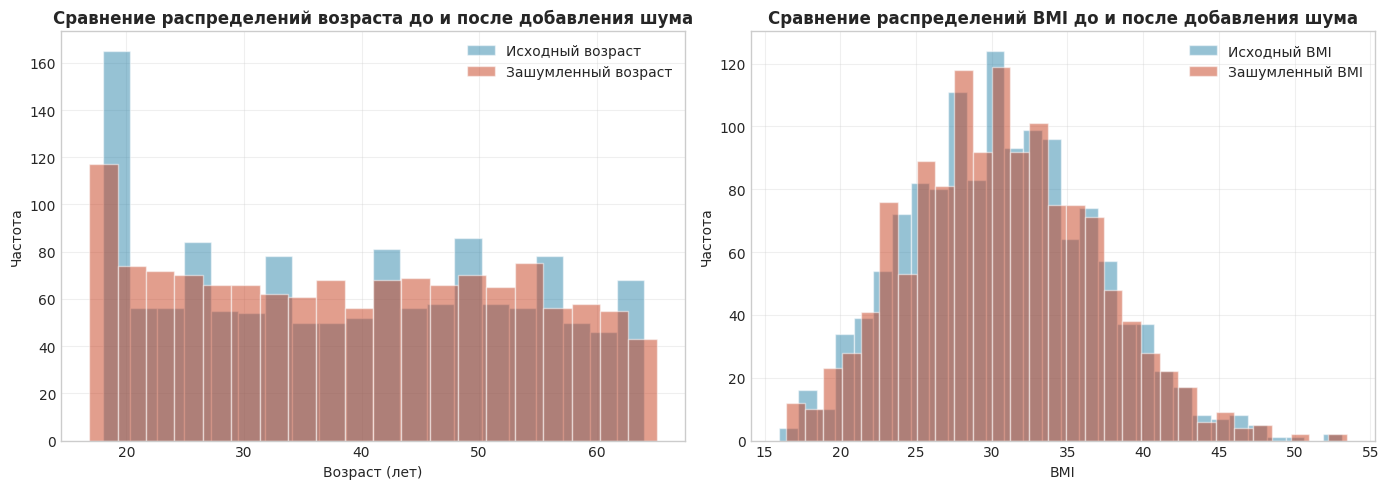

Датасет с зашумленными признаками сохранён: C:\Users\palee\Google Диск\Школа\хелп\Проектная деятельность/insurance_with_noise.csv

Примеры 5 случайных записей (сравнение исходных и зашумленных значений):


,age_orig,age_noisy,bmi_orig,bmi_noisy
0,18,17.71,24.090,24.17
1,58,56.89,27.170,27.36
2,48,47.55,35.625,35.87
3,35,35.77,30.500,30.65
4,32,32.95,33.155,33.10


In [ ]:
# =========================================================================================
# 1.3 Характеристика числовых признаков
# 1.3.9	Добавление шума
# =========================================================================================
# Установка seed для воспроизводимости
np.random.seed(42)

print("=" * 60)
print("1.3.9. ДОБАВЛЕНИЕ ШУМА К ПРИЗНАКАМ")
print("=" * 60)

output_dir = r"C:\Users\palee\Google Диск\Школа\хелп\Проектная деятельность"
os.makedirs(output_dir, exist_ok=True)

# Копируем датафрейм для добавления шума
df_noisy = df.copy()

# ---------- 1. Добавление шума к признаку 'age' ----------
# Возраст записан с точностью до года, но реальный возраст непрерывен.
# Добавим небольшой гауссов шум со стандартным отклонением 0.5 года.
age_noise = np.random.normal(0, 0.5, size=len(df))
df_noisy['age_noisy'] = df['age'] + age_noise
# Ограничим возраст разумными пределами (оставим как есть, т.к. шум мал)

print("\n--- Добавление шума к признаку 'age' ---")
print(f"Исходный возраст: среднее = {df['age'].mean():.3f}, std = {df['age'].std():.3f}")
print(f"Зашумленный возраст: среднее = {df_noisy['age_noisy'].mean():.3f}, std = {df_noisy['age_noisy'].std():.3f}")
print(f"Корреляция между исходным и зашумленным возрастом: {df['age'].corr(df_noisy['age_noisy']):.6f}")

# ---------- 2. Добавление шума к признаку 'bmi' ----------
# ИМТ может иметь погрешность измерения. Добавим шум с std = 0.3.
bmi_noise = np.random.normal(0, 0.3, size=len(df))
df_noisy['bmi_noisy'] = df['bmi'] + bmi_noise

print("\n--- Добавление шума к признаку 'bmi' ---")
print(f"Исходный BMI: среднее = {df['bmi'].mean():.3f}, std = {df['bmi'].std():.3f}")
print(f"Зашумленный BMI: среднее = {df_noisy['bmi_noisy'].mean():.3f}, std = {df_noisy['bmi_noisy'].std():.3f}")
print(f"Корреляция между исходным и зашумленным BMI: {df['bmi'].corr(df_noisy['bmi_noisy']):.6f}")

# ---------- 3. Визуализация исходных и зашумленных распределений ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Возраст
axes[0].hist(df['age'], bins=20, alpha=0.5, label='Исходный возраст', color='#2E86AB', edgecolor='white')
axes[0].hist(df_noisy['age_noisy'], bins=20, alpha=0.5, label='Зашумленный возраст', color='#C73E1D', edgecolor='white')
axes[0].set_title('Сравнение распределений возраста до и после добавления шума', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Возраст (лет)')
axes[0].set_ylabel('Частота')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# BMI
axes[1].hist(df['bmi'], bins=30, alpha=0.5, label='Исходный BMI', color='#2E86AB', edgecolor='white')
axes[1].hist(df_noisy['bmi_noisy'], bins=30, alpha=0.5, label='Зашумленный BMI', color='#C73E1D', edgecolor='white')
axes[1].set_title('Сравнение распределений BMI до и после добавления шума', fontsize=12, fontweight='bold')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Частота')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
noise_plot_path = os.path.join(output_dir, 'noise_comparison_hist.png')
plt.savefig(noise_plot_path, dpi=300, bbox_inches='tight')
print(f"\nГрафик сравнения распределений сохранён: {noise_plot_path}")
plt.show()

# ---------- 4. Сохранение датасета с зашумленными признаками ----------
# Создадим версию датафрейма, где исходные признаки заменены на зашумленные
df_noisy_final = df_noisy.drop(['age', 'bmi'], axis=1).rename(columns={'age_noisy': 'age', 'bmi_noisy': 'bmi'})
# Вернём правильный порядок столбцов
cols = ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']
df_noisy_final = df_noisy_final[cols]

noisy_path = os.path.join(output_dir, 'insurance_with_noise.csv')
df_noisy_final.to_csv(noisy_path, index=False)
print(f"Датасет с зашумленными признаками сохранён: {noisy_path}")

# ---------- 5. Примеры записей до и после зашумления ----------
print("\nПримеры 5 случайных записей (сравнение исходных и зашумленных значений):")
sample_indices = np.random.choice(len(df), 5, replace=False)
comparison = pd.DataFrame({
    'age_orig': df.loc[sample_indices, 'age'].values,
    'age_noisy': df_noisy.loc[sample_indices, 'age_noisy'].values.round(2),
    'bmi_orig': df.loc[sample_indices, 'bmi'].values,
    'bmi_noisy': df_noisy.loc[sample_indices, 'bmi_noisy'].values.round(2)
})
display(comparison)

1.3.10. ПРЕОБРАЗОВАНИЕ ЧИСЛОВЫХ ДАННЫХ В КАТЕГОРИАЛЬНЫЕ

--- Анализ распределения возраста ---
count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

Возрасты, встречающиеся менее 5 раз: 0 значений

--- Анализ распределения BMI ---
count    1338.000000
mean       30.663397
std         6.098187
min        15.960000
25%        26.296250
50%        30.400000
75%        34.693750
max        53.130000
Name: bmi, dtype: float64

Округлённых значений BMI, встречающихся менее 5 раз: 6
Диапазон BMI: от 16.0 до 53.1

--- Распределение по возрастным группам ---
18-29 лет: 417 (31.2%)
30-39 лет: 257 (19.2%)
40-49 лет: 279 (20.9%)
50-59 лет: 271 (20.3%)
60-64 лет: 114 (8.5%)

--- Распределение по категориям BMI (ВОЗ) ---
Недостаточный вес: 20 (1.5%)
Норма: 225 (16.8%)
Избыточный вес: 386 (28.8%)
Ожирение I ст.: 391 (29.2%)
Ожирение II ст.: 225 (16.8%)
Ожирение 

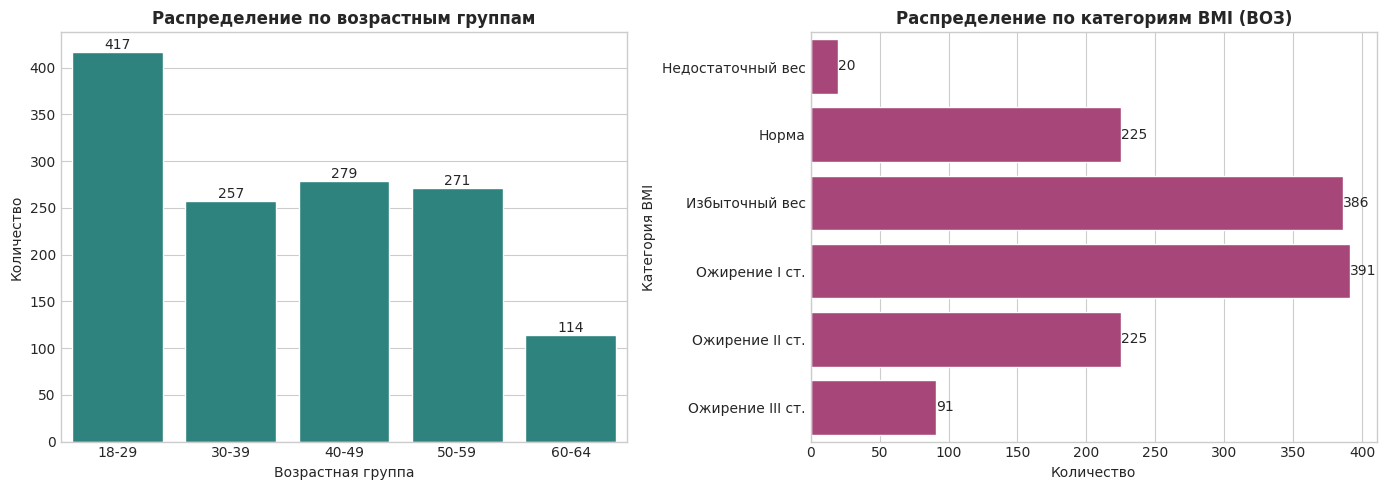

Датасет с категориальными признаками сохранён: C:\Users\palee\Google Диск\Школа\хелп\Проектная деятельность/insurance_categorical.csv
Датасет с заменой числовых признаков на категориальные сохранён: C:\Users\palee\Google Диск\Школа\хелп\Проектная деятельность/insurance_only_categorical.csv


In [ ]:
# =========================================================================================
# 1.3 Характеристика числовых признаков
# 1.3.10	Преобразование числовых данных в категориальные
# =========================================================================================
print("=" * 60)
print("1.3.10. ПРЕОБРАЗОВАНИЕ ЧИСЛОВЫХ ДАННЫХ В КАТЕГОРИАЛЬНЫЕ")
print("=" * 60)

output_dir = r"C:\Users\palee\Google Диск\Школа\хелп\Проектная деятельность"
os.makedirs(output_dir, exist_ok=True)

# Копия датафрейма для преобразований
df_cat = df.copy()

# ---------- 1. Анализ распределения возраста и BMI ----------
print("\n--- Анализ распределения возраста ---")
print(df['age'].describe())
age_counts = df['age'].value_counts().sort_index()
rare_ages = age_counts[age_counts < 5]
print(f"\nВозрасты, встречающиеся менее 5 раз: {len(rare_ages)} значений")
if len(rare_ages) > 0:
    print("Примеры редких возрастов:", list(rare_ages.index[:5]))

print("\n--- Анализ распределения BMI ---")
print(df['bmi'].describe())
bmi_rounded = df['bmi'].round().astype(int)
bmi_counts = bmi_rounded.value_counts().sort_index()
rare_bmi = bmi_counts[bmi_counts < 5]
print(f"\nОкруглённых значений BMI, встречающихся менее 5 раз: {len(rare_bmi)}")
print(f"Диапазон BMI: от {df['bmi'].min():.1f} до {df['bmi'].max():.1f}")

# ---------- 2. Категоризация возраста по десятилетиям ----------
bins_age = [17, 30, 40, 50, 60, 65]
labels_age = ['18-29', '30-39', '40-49', '50-59', '60-64']
df_cat['age_group'] = pd.cut(df['age'], bins=bins_age, labels=labels_age, right=False)

print("\n--- Распределение по возрастным группам ---")
age_group_counts = df_cat['age_group'].value_counts().sort_index()
for group, count in age_group_counts.items():
    print(f"{group} лет: {count} ({100*count/len(df_cat):.1f}%)")

# ---------- 3. Категоризация BMI по стандартам ВОЗ ----------
def bmi_category(bmi):
    if bmi < 18.5:
        return 'Недостаточный вес'
    elif 18.5 <= bmi < 25:
        return 'Норма'
    elif 25 <= bmi < 30:
        return 'Избыточный вес'
    elif 30 <= bmi < 35:
        return 'Ожирение I ст.'
    elif 35 <= bmi < 40:
        return 'Ожирение II ст.'
    else:
        return 'Ожирение III ст.'

df_cat['bmi_category'] = df['bmi'].apply(bmi_category)

print("\n--- Распределение по категориям BMI (ВОЗ) ---")
bmi_cat_counts = df_cat['bmi_category'].value_counts().reindex([
    'Недостаточный вес', 'Норма', 'Избыточный вес',
    'Ожирение I ст.', 'Ожирение II ст.', 'Ожирение III ст.'
])
for cat, count in bmi_cat_counts.items():
    print(f"{cat}: {count} ({100*count/len(df_cat):.1f}%)")

# ---------- 4. Визуализация новых категориальных признаков ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Возрастные группы:
df_cat['_dummy'] = 'Все'
sns.countplot(data=df_cat, x='age_group', hue='_dummy', palette='viridis',
              ax=axes[0], order=labels_age, legend=False)
axes[0].set_title('Распределение по возрастным группам', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Возрастная группа')
axes[0].set_ylabel('Количество')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10)

# Категории BMI:
order_bmi = ['Недостаточный вес', 'Норма', 'Избыточный вес',
             'Ожирение I ст.', 'Ожирение II ст.', 'Ожирение III ст.']
sns.countplot(data=df_cat, y='bmi_category', hue='_dummy', palette='magma',
              ax=axes[1], order=order_bmi, legend=False)
axes[1].set_title('Распределение по категориям BMI (ВОЗ)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Количество')
axes[1].set_ylabel('Категория BMI')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_width())}',
                     (p.get_width(), p.get_y() + p.get_height() / 2.),
                     ha='left', va='center', fontsize=10)

plt.tight_layout()
cat_plot_path = os.path.join(output_dir, 'categorical_transformation.png')
plt.savefig(cat_plot_path, dpi=300, bbox_inches='tight')
print(f"\nГрафик распределения категорий сохранён: {cat_plot_path}")
plt.show()

# Удаляем вспомогательный столбец
df_cat.drop('_dummy', axis=1, inplace=True)

# ---------- 5. Сохранение датасета с новыми категориальными признаками ----------
df_cat_full = df_cat.copy()
cat_path = os.path.join(output_dir, 'insurance_categorical.csv')
df_cat_full.to_csv(cat_path, index=False)
print(f"Датасет с категориальными признаками сохранён: {cat_path}")

df_cat_only = df_cat.drop(['age', 'bmi'], axis=1)
cat_only_path = os.path.join(output_dir, 'insurance_only_categorical.csv')
df_cat_only.to_csv(cat_only_path, index=False)
print(f"Датасет с заменой числовых признаков на категориальные сохранён: {cat_only_path}")

1.3.12. ОЦЕНКА ИЗМЕНЕНИЯ В ДАННЫХ ПОСЛЕ ФИЛЬТРАЦИИ
Сравнительные гистограммы сохранены: C:\Users\palee\Google Диск\Школа\хелп\Проектная деятельность/comparison_before_after_histograms.png


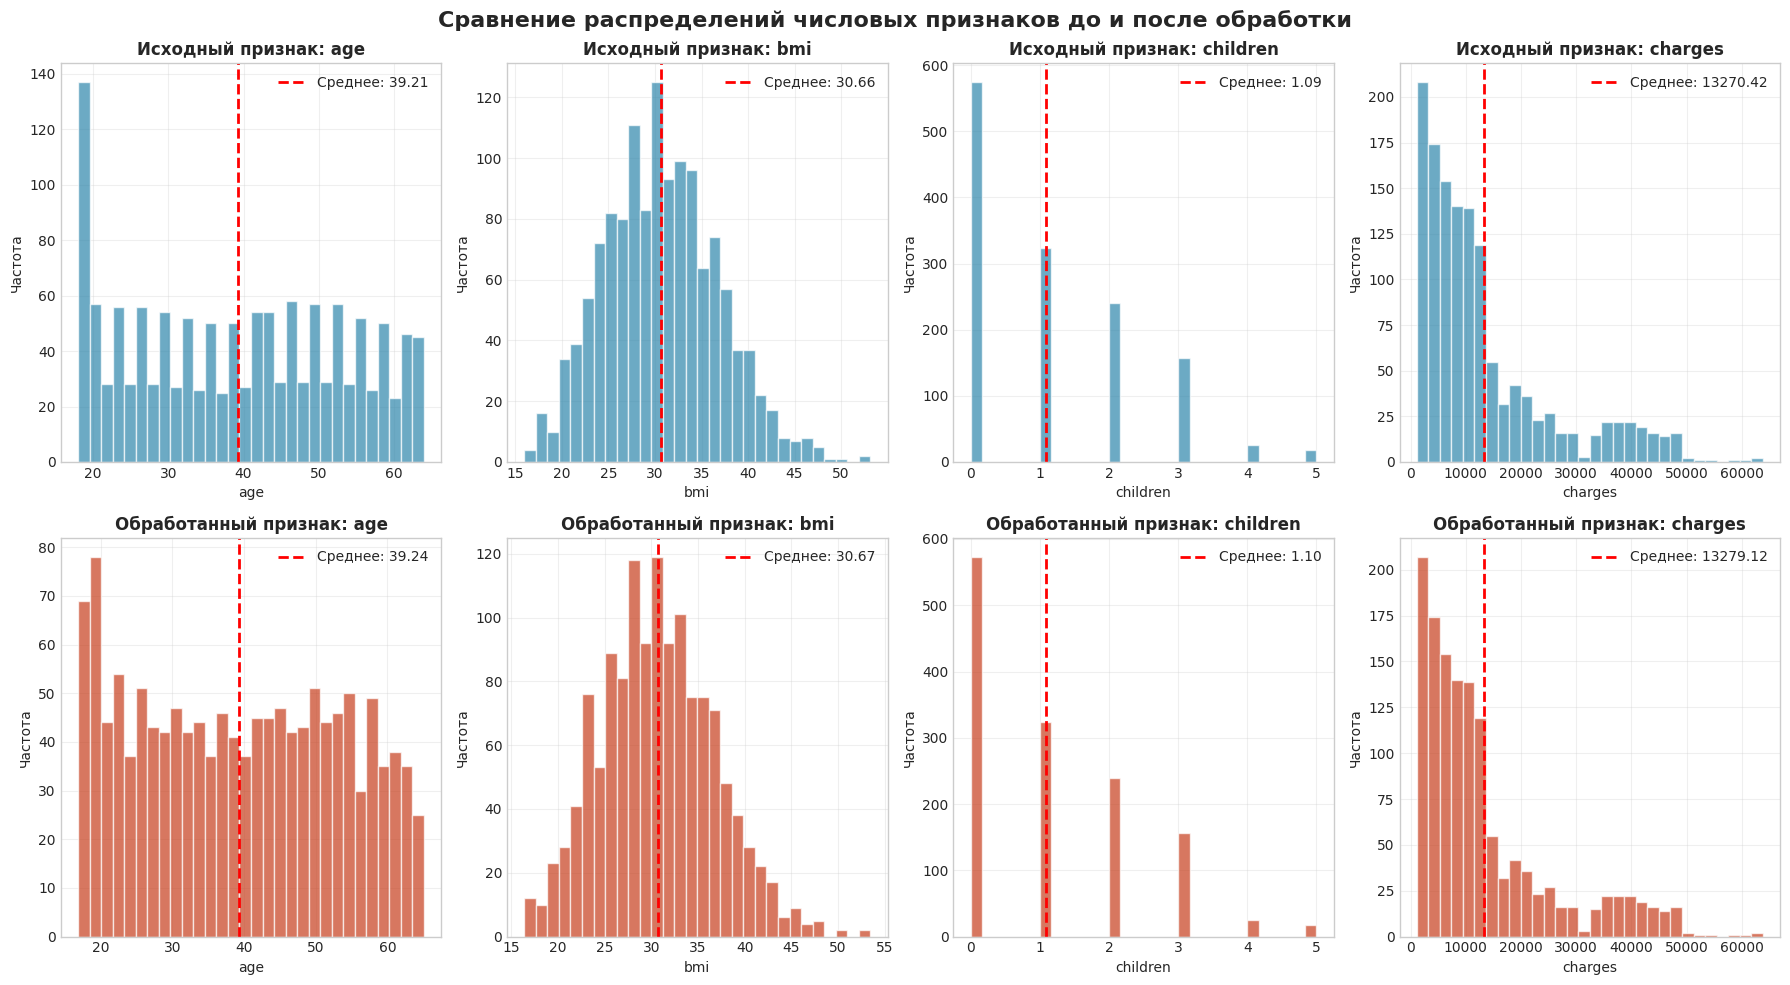


Сравнение основных статистик до и после обработки:

--- age ---
Среднее: исходное = 39.2070, обработанное = 39.2413 (изменение: +0.0342)
Стд.откл: исходное = 14.0500, обработанное = 14.0440 (изменение: -0.0059)

--- bmi ---
Среднее: исходное = 30.6634, обработанное = 30.6725 (изменение: +0.0091)
Стд.откл: исходное = 6.0982, обработанное = 6.1016 (изменение: +0.0034)

--- children ---
Среднее: исходное = 1.0949, обработанное = 1.0957 (изменение: +0.0008)
Стд.откл: исходное = 1.2055, обработанное = 1.2056 (изменение: +0.0001)

--- charges ---
Среднее: исходное = 13270.4223, обработанное = 13279.1215 (изменение: +8.6992)
Стд.откл: исходное = 12110.0112, обработанное = 12110.3597 (изменение: +0.3484)

Количество записей до обработки: 1338
Количество записей после обработки: 1337 (удалён 1 дубликат)


In [ ]:
# =========================================================================================
# 1.3 Характеристика числовых признаков
# 1.3.12	Оценка изменения в данных после фильтрации
# =========================================================================================
df_original = pd.read_csv('insurance.csv')
df_processed = pd.read_csv(os.path.join(output_dir, 'insurance_with_noise.csv'))

print("=" * 60)
print("1.3.12. ОЦЕНКА ИЗМЕНЕНИЯ В ДАННЫХ ПОСЛЕ ФИЛЬТРАЦИИ")
print("=" * 60)

output_dir = r"C:\Users\palee\Google Диск\Школа\хелп\Проектная деятельность"
os.makedirs(output_dir, exist_ok=True)

# Список числовых признаков для сравнения
numeric_cols = ['age', 'bmi', 'children', 'charges']

# ---------- 1. Сравнительная визуализация гистограмм ----------
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('Сравнение распределений числовых признаков до и после обработки', fontsize=16, fontweight='bold')

for i, col in enumerate(numeric_cols):
    # Исходные данные (с дубликатом)
    axes[0, i].hist(df_original[col], bins=30, color='#2E86AB', alpha=0.7, edgecolor='white')
    axes[0, i].axvline(df_original[col].mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее: {df_original[col].mean():.2f}')
    axes[0, i].set_title(f'Исходный признак: {col}', fontsize=12, fontweight='bold')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Частота')
    axes[0, i].legend()
    axes[0, i].grid(True, alpha=0.3)

    # Обработанные данные (после удаления дубликата и добавления шума)
    axes[1, i].hist(df_processed[col], bins=30, color='#C73E1D', alpha=0.7, edgecolor='white')
    axes[1, i].axvline(df_processed[col].mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее: {df_processed[col].mean():.2f}')
    axes[1, i].set_title(f'Обработанный признак: {col}', fontsize=12, fontweight='bold')
    axes[1, i].set_xlabel(col)
    axes[1, i].set_ylabel('Частота')
    axes[1, i].legend()
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
compare_path = os.path.join(output_dir, 'comparison_before_after_histograms.png')
plt.savefig(compare_path, dpi=300, bbox_inches='tight')
print(f"Сравнительные гистограммы сохранены: {compare_path}")
plt.show()

# ---------- 2. Количественное сравнение статистик ----------
print("\nСравнение основных статистик до и после обработки:")
for col in numeric_cols:
    print(f"\n--- {col} ---")
    orig_mean = df_original[col].mean()
    proc_mean = df_processed[col].mean()
    orig_std = df_original[col].std()
    proc_std = df_processed[col].std()
    print(f"Среднее: исходное = {orig_mean:.4f}, обработанное = {proc_mean:.4f} (изменение: {proc_mean - orig_mean:+.4f})")
    print(f"Стд.откл: исходное = {orig_std:.4f}, обработанное = {proc_std:.4f} (изменение: {proc_std - orig_std:+.4f})")

# ---------- 3. Анализ изменения размера выборки ----------
print(f"\nКоличество записей до обработки: {len(df_original)}")
print(f"Количество записей после обработки: {len(df_processed)} (удалён 1 дубликат)")

In [ ]:
# =========================================================================================
# 1.4	Характеристика категориальных данных
# 1.4.1	Перечисление всех категорий по признакам
# =========================================================================================
print("=" * 60)
print("1.4.1. ПЕРЕЧИСЛЕНИЕ ВСЕХ КАТЕГОРИЙ ПО ПРИЗНАКАМ")
print("=" * 60)

categorical_cols = ['sex', 'smoker', 'region']

print("\nУникальные значения категориальных признаков:\n")
for col in categorical_cols:
    unique_vals = sorted(df[col].unique())
    print(f"Признак '{col}':")
    for val in unique_vals:
        count = (df[col] == val).sum()
        print(f"  - {val} ({count} записей)")
    print()

1.4.1. ПЕРЕЧИСЛЕНИЕ ВСЕХ КАТЕГОРИЙ ПО ПРИЗНАКАМ

Уникальные значения категориальных признаков:

Признак 'sex':
  - female (662 записей)
  - male (675 записей)

Признак 'smoker':
  - no (1063 записей)
  - yes (274 записей)

Признак 'region':
  - northeast (324 записей)
  - northwest (324 записей)
  - southeast (364 записей)
  - southwest (325 записей)




1.4.2. ДИАГРАММЫ РАСПРЕДЕЛЕНИЯ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ
Диаграммы распределения сохранены в: C:\Users\palee\Google Диск\Школа\хелп\Проектная деятельность/categorical_distribution.png


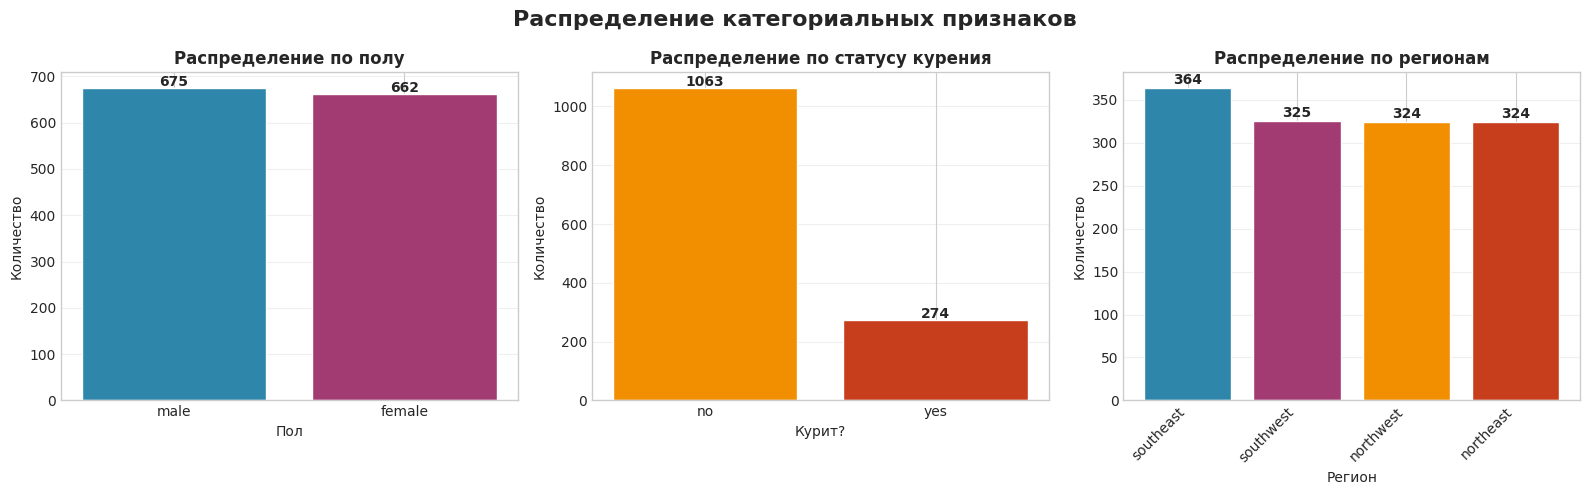

In [ ]:
# =========================================================================================
# 1.4	Характеристика категориальных данных
# 1.4.2	Диаграммы распределения категориальных данных
# =========================================================================================
# Настройка стиля
sns.set_style("whitegrid")
output_dir = r"C:\Users\palee\Google Диск\Школа\хелп\Проектная деятельность"
os.makedirs(output_dir, exist_ok=True)

print("\n" + "=" * 60)
print("1.4.2. ДИАГРАММЫ РАСПРЕДЕЛЕНИЯ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")
print("=" * 60)

# Цветовая палитра
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Распределение категориальных признаков', fontsize=16, fontweight='bold')

# 1. Пол (sex)
sex_counts = df['sex'].value_counts()
axes[0].bar(sex_counts.index, sex_counts.values, color=[colors[0], colors[1]], edgecolor='white')
axes[0].set_title('Распределение по полу', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Пол')
axes[0].set_ylabel('Количество')
for i, v in enumerate(sex_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# 2. Статус курения (smoker)
smoker_counts = df['smoker'].value_counts()
axes[1].bar(smoker_counts.index, smoker_counts.values, color=[colors[2], colors[3]], edgecolor='white')
axes[1].set_title('Распределение по статусу курения', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Курит?')
axes[1].set_ylabel('Количество')
for i, v in enumerate(smoker_counts.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# 3. Регион (region)
region_counts = df['region'].value_counts()
axes[2].bar(region_counts.index, region_counts.values, color=colors[:4], edgecolor='white')
axes[2].set_title('Распределение по регионам', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Регион')
axes[2].set_ylabel('Количество')
for i, v in enumerate(region_counts.values):
    axes[2].text(i, v + 5, str(v), ha='center', fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
cat_dist_path = os.path.join(output_dir, 'categorical_distribution.png')
plt.savefig(cat_dist_path, dpi=300, bbox_inches='tight')
print(f"Диаграммы распределения сохранены в: {cat_dist_path}")
plt.show()

In [ ]:
# =========================================================================================
# 1.4	Характеристика категориальных данных
# 1.4.3	Преобразование категориальных данных в числовые
# =========================================================================================
from sklearn.preprocessing import LabelEncoder

print("=" * 60)
print("1.4.3. ПРЕОБРАЗОВАНИЕ КАТЕГОРИАЛЬНЫХ ДАННЫХ В ЧИСЛОВЫЕ")
print("=" * 60)

output_dir = r"C:\Users\palee\Google Диск\Школа\хелп\Проектная деятельность"
os.makedirs(output_dir, exist_ok=True)

# Создаём копию для экспериментов
df_encoded = df.copy()

# ---------- 1. Label Encoding для бинарных признаков ----------
print("\n--- 1. Label Encoding для бинарных признаков ---")

# Признак 'sex': female -> 0, male -> 1
le_sex = LabelEncoder()
df_encoded['sex_encoded'] = le_sex.fit_transform(df['sex'])
print(f"Соответствие для 'sex': {dict(zip(le_sex.classes_, le_sex.transform(le_sex.classes_)))}")

# Признак 'smoker': no -> 0, yes -> 1
le_smoker = LabelEncoder()
df_encoded['smoker_encoded'] = le_smoker.fit_transform(df['smoker'])
print(f"Соответствие для 'smoker': {dict(zip(le_smoker.classes_, le_smoker.transform(le_smoker.classes_)))}")

# ---------- 2. One-Hot Encoding для мультиклассового признака ----------
print("\n--- 2. One-Hot Encoding для признака 'region' ---")

# Создаём дамми-переменные
region_dummies = pd.get_dummies(df['region'], prefix='region', dtype=int)
df_encoded = pd.concat([df_encoded, region_dummies], axis=1)

print("Созданы столбцы:")
for col in region_dummies.columns:
    print(f"  - {col}")

# ---------- 3. Frequency Encoding для признака 'region' ----------
print("\n--- 3. Frequency Encoding для признака 'region' ---")

# Частота встречаемости каждой категории
freq_map = df['region'].value_counts(normalize=True)
df_encoded['region_freq'] = df['region'].map(freq_map)

print("Частоты категорий региона:")
for region, freq in freq_map.items():
    print(f"  {region}: {freq:.4f}")

# ---------- 4. Просмотр преобразованных данных ----------
print("\nПример данных после преобразований (первые 5 строк):")
display(df_encoded[['sex', 'sex_encoded', 'smoker', 'smoker_encoded',
                    'region', 'region_northeast', 'region_northwest',
                    'region_southeast', 'region_southwest', 'region_freq']].head())

# ---------- 5. Сохранение преобразованных датасетов ----------
# Полный датасет со всеми кодировками
full_encoded_path = os.path.join(output_dir, 'insurance_all_encodings.csv')
df_encoded.to_csv(full_encoded_path, index=False)
print(f"\nДатасет со всеми кодировками сохранён: {full_encoded_path}")

# Датасет с заменой категориальных признаков на числовые (только числовые данные)
df_numeric = df_encoded.drop(['sex', 'smoker', 'region'], axis=1)
numeric_only_path = os.path.join(output_dir, 'insurance_numeric_only.csv')
df_numeric.to_csv(numeric_only_path, index=False)
print(f"Датасет только с числовыми признаками сохранён: {numeric_only_path}")

# Вариант с One-Hot Encoding (замена region на дамми, sex/smoker - числовые метки)
df_onehot = df_encoded.drop(['region', 'region_freq', 'sex', 'smoker'], axis=1)
onehot_path = os.path.join(output_dir, 'insurance_onehot.csv')
df_onehot.to_csv(onehot_path, index=False)
print(f"Датасет с One-Hot Encoding для region и Label Encoding для sex/smoker: {onehot_path}")

1.4.3. ПРЕОБРАЗОВАНИЕ КАТЕГОРИАЛЬНЫХ ДАННЫХ В ЧИСЛОВЫЕ

--- 1. Label Encoding для бинарных признаков ---
Соответствие для 'sex': {'female': np.int64(0), 'male': np.int64(1)}
Соответствие для 'smoker': {'no': np.int64(0), 'yes': np.int64(1)}

--- 2. One-Hot Encoding для признака 'region' ---
Созданы столбцы:
  - region_northeast
  - region_northwest
  - region_southeast
  - region_southwest

--- 3. Frequency Encoding для признака 'region' ---
Частоты категорий региона:
  southeast: 0.2723
  southwest: 0.2431
  northwest: 0.2423
  northeast: 0.2423

Пример данных после преобразований (первые 5 строк):


,sex,sex_encoded,smoker,smoker_encoded,region,region_northeast,region_northwest,region_southeast,region_southwest,region_freq
0,female,0,yes,1,southwest,0,0,0,1,0.243082
1,male,1,no,0,southeast,0,0,1,0,0.272251
2,male,1,no,0,southeast,0,0,1,0,0.272251
3,male,1,no,0,northwest,0,1,0,0,0.242334
4,male,1,no,0,northwest,0,1,0,0,0.242334



Датасет со всеми кодировками сохранён: C:\Users\palee\Google Диск\Школа\хелп\Проектная деятельность/insurance_all_encodings.csv
Датасет только с числовыми признаками сохранён: C:\Users\palee\Google Диск\Школа\хелп\Проектная деятельность/insurance_numeric_only.csv
Датасет с One-Hot Encoding для region и Label Encoding для sex/smoker: C:\Users\palee\Google Диск\Школа\хелп\Проектная деятельность/insurance_onehot.csv


In [ ]:
# =========================================================================================
# 1.4	Характеристика категориальных данных
# 1.4.4	Агрегация данных
# =========================================================================================
print("=" * 60)
print("1.4.4. АГРЕГАЦИЯ ДАННЫХ (ПРОВЕРКА НА РЕДКИЕ КАТЕГОРИИ)")
print("=" * 60)

categorical_cols = ['sex', 'smoker', 'region']
threshold = 0.05  # 5% порог

print("\nАнализ частот категорий:\n")
rare_found = False

for col in categorical_cols:
    counts = df[col].value_counts(normalize=True)
    print(f"Признак '{col}':")
    for cat, freq in counts.items():
        print(f"  {cat}: {freq:.2%}")
        if freq < threshold:
            rare_found = True
            print(f"    -> Внимание: редкая категория (менее {threshold:.0%})")
    print()

if rare_found:
    print("Обнаружены редкие категории. Требуется агрегация (например, объединение редких значений в категорию 'другое').")
else:
    print("Редкие категории отсутствуют. Все категории представлены более чем в 5% наблюдений.")
    print("Вывод: Агрегация данных по категориальным признакам не требуется.")

1.4.4. АГРЕГАЦИЯ ДАННЫХ (ПРОВЕРКА НА РЕДКИЕ КАТЕГОРИИ)

Анализ частот категорий:

Признак 'sex':
  male: 50.49%
  female: 49.51%

Признак 'smoker':
  no: 79.51%
  yes: 20.49%

Признак 'region':
  southeast: 27.23%
  southwest: 24.31%
  northwest: 24.23%
  northeast: 24.23%

Редкие категории отсутствуют. Все категории представлены более чем в 5% наблюдений.
Вывод: Агрегация данных по категориальным признакам не требуется.


1.4.5. ВВЕДЕНИЕ НОВОЙ КАТЕГОРИИ

Распределение по группам риска:
  Некурящий с ожирением (умеренный риск): 561 (42.0%)
  Некурящий без ожирения (низкий риск): 502 (37.5%)
  Курящий с ожирением (высокий риск): 145 (10.8%)
  Курящий без ожирения (повышенный риск): 129 (9.6%)

Средние медицинские расходы по группам риска:
  Курящий без ожирения (повышенный риск): $21,363.22
  Курящий с ожирением (высокий риск): $41,557.99
  Некурящий без ожирения (низкий риск): $7,977.03
  Некурящий с ожирением (умеренный риск): $8,855.53

График распределения групп риска сохранён: C:\Users\palee\Google Диск\Школа\хелп\Проектная деятельность/risk_group_distribution.png


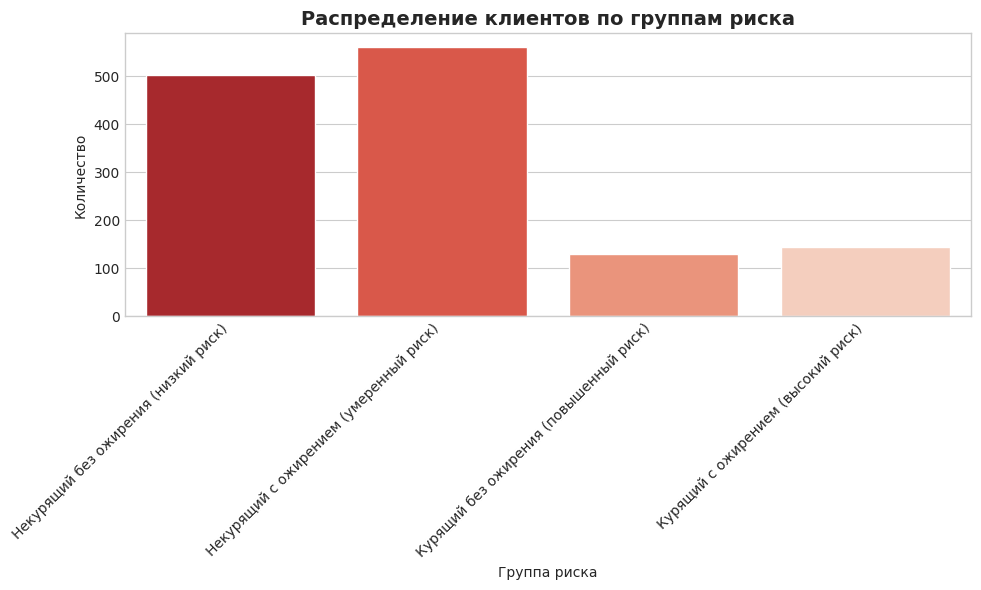

Датасет с новой категорией сохранён: C:\Users\palee\Google Диск\Школа\хелп\Проектная деятельность/insurance_with_risk_group.csv


In [ ]:
# =========================================================================================
# 1.4	Характеристика категориальных данных
# 1.4.5	Введение новой категории
# =========================================================================================
print("=" * 60)
print("1.4.5. ВВЕДЕНИЕ НОВОЙ КАТЕГОРИИ")
print("=" * 60)

output_dir = r"C:\Users\palee\Google Диск\Школа\хелп\Проектная деятельность"
os.makedirs(output_dir, exist_ok=True)

# ---------- 1. Определение функции для новой категории ----------
def assign_risk_group(row):
    """
    Категория риска на основе BMI и статуса курения.
    Курение является доминирующим фактором.
    """
    if row['smoker'] == 'yes':
        if row['bmi'] >= 30:
            return 'Курящий с ожирением (высокий риск)'
        else:
            return 'Курящий без ожирения (повышенный риск)'
    else:  # не курит
        if row['bmi'] >= 30:
            return 'Некурящий с ожирением (умеренный риск)'
        else:
            return 'Некурящий без ожирения (низкий риск)'

df['risk_group'] = df.apply(assign_risk_group, axis=1)

# ---------- 2. Анализ новой категории ----------
print("\nРаспределение по группам риска:")
risk_counts = df['risk_group'].value_counts()
risk_pct = df['risk_group'].value_counts(normalize=True) * 100
for group in risk_counts.index:
    print(f"  {group}: {risk_counts[group]} ({risk_pct[group]:.1f}%)")

# Средние расходы по группам риска
print("\nСредние медицинские расходы по группам риска:")
risk_charges = df.groupby('risk_group')['charges'].mean().round(2)
for group, charge in risk_charges.items():
    print(f"  {group}: ${charge:,.2f}")

# ---------- 3. Визуализация ----------
plt.figure(figsize=(10, 6))
order = ['Некурящий без ожирения (низкий риск)',
         'Некурящий с ожирением (умеренный риск)',
         'Курящий без ожирения (повышенный риск)',
         'Курящий с ожирением (высокий риск)']
sns.barplot(x=df['risk_group'].value_counts().reindex(order).index,
            y=df['risk_group'].value_counts().reindex(order).values,
            hue=df['risk_group'].value_counts().reindex(order).index,
            palette='Reds_r', legend=False)
plt.title('Распределение клиентов по группам риска', fontsize=14, fontweight='bold')
plt.xlabel('Группа риска')
plt.ylabel('Количество')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plot_path = os.path.join(output_dir, 'risk_group_distribution.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"\nГрафик распределения групп риска сохранён: {plot_path}")
plt.show()

# ---------- 4. Сохранение обновлённого датасета ----------
output_path = os.path.join(output_dir, 'insurance_with_risk_group.csv')
df.to_csv(output_path, index=False)
print(f"Датасет с новой категорией сохранён: {output_path}")